In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import seaborn as sns
import plotly.graph_objects as go
from plotly.offline import iplot
from statsmodels.tsa.stattools import adfuller
from utils import globals

In [2]:
train = None
with open("../../Data/PHM2025_training_data/training_data.csv", "r") as f:
    train = pd.read_csv(f)

train.head()

,ESN,Cycles_Since_New,Snapshot,Cumulative_WWs,Cumulative_HPC_SVs,Cumulative_HPT_SVs,Sensed_Altitude,Sensed_Mach,Sensed_Pamb,Sensed_Pt2,...,Sensed_Core_Speed,Sensed_T25,Sensed_T3,Sensed_Ps3,Sensed_T45,Sensed_P25,Sensed_T5,Cycles_to_WW,Cycles_to_HPC_SV,Cycles_to_HPT_SV
0,101,0,1,0,0,0,851.321516,0.103224,14.250475,14.289459,...,21261.365607,744.009196,1609.417021,474.158862,2173.316575,40.065810,1415.477470,910,8510,4090
1,101,0,2,0,0,0,903.321516,0.213663,14.224853,14.628042,...,21280.040466,747.318490,1612.148051,483.190299,2172.105766,41.152081,1409.643967,910,8510,4090
2,101,0,3,0,0,0,3410.321516,0.345333,12.989563,14.055733,...,21014.282876,735.730180,1576.031353,442.421527,2106.463686,38.758249,1365.412495,910,8510,4090
3,101,0,4,0,0,0,20259.321516,0.619005,6.679796,8.621275,...,20466.466115,706.293618,1504.811122,283.988928,2016.969960,25.574967,1256.689540,910,8510,4090
4,101,0,6,0,0,0,21991.321516,0.640425,6.230955,8.183755,...,20313.501657,699.650483,1484.629857,261.543915,1984.370026,23.927579,1238.665408,910,8510,4090


In [3]:
# Conteggio numero di righe totali e per motore
rows = len(train)
print(f"Numero totale di righe: {rows}")
print(f"\nNumero di righe per ogni motore:")
train.groupby('ESN').size()

Numero totale di righe: 59702

Numero di righe per ogni motore:


ESN
101    14738
102    15044
103    14856
104    15064
dtype: int64

In [4]:
# Conteggio dei valori nulli per colonna
train.isnull().sum()

# Colonne con valori nulli:
# - Sensed_WFuel : peso misurato del carburante
# - Sensed_Core_Speed : velocità di rotazione misurata dello 
#   spool ad alta pressione, che comprende l'albero con il HPC e la HPT
# - Sensed_T3 : temperatura dell'aria misurata in uscita al HPC
# - Sensed_Ps3 : pressione misurata in uscita al HPC
# - Sensed_T45 : temperatura del gas combusto misurata all'uscita della HPT
# - Sensed_T5 : temperatura misurata all'uscita della turbina a bassa pressione

ESN                     0
Cycles_Since_New        0
Snapshot                0
Cumulative_WWs          0
Cumulative_HPC_SVs      0
Cumulative_HPT_SVs      0
Sensed_Altitude         0
Sensed_Mach             0
Sensed_Pamb             0
Sensed_Pt2              0
Sensed_TAT              0
Sensed_WFuel          697
Sensed_VAFN             0
Sensed_VBV              0
Sensed_Fan_Speed        0
Sensed_Core_Speed     697
Sensed_T25              0
Sensed_T3              60
Sensed_Ps3             60
Sensed_T45            757
Sensed_P25              0
Sensed_T5             757
Cycles_to_WW            0
Cycles_to_HPC_SV        0
Cycles_to_HPT_SV        0
dtype: int64

In [5]:
# Conteggio dei valori nulli per ogni motore
train.groupby('ESN').apply(lambda x: x.isnull().sum(), include_groups=False)

# Da valutare 
# Sono presenti maggiormente nel motore 104

,Cycles_Since_New,Snapshot,Cumulative_WWs,Cumulative_HPC_SVs,Cumulative_HPT_SVs,Sensed_Altitude,Sensed_Mach,Sensed_Pamb,Sensed_Pt2,Sensed_TAT,...,Sensed_Core_Speed,Sensed_T25,Sensed_T3,Sensed_Ps3,Sensed_T45,Sensed_P25,Sensed_T5,Cycles_to_WW,Cycles_to_HPC_SV,Cycles_to_HPT_SV
ESN,,,,,,,,,,,,,,,,,,,,,
101,0,0,0,0,0,0,0,0,0,0,...,13,0,0,0,13,0,13,0,0,0
102,0,0,0,0,0,0,0,0,0,0,...,13,0,5,5,18,0,18,0,0,0
103,0,0,0,0,0,0,0,0,0,0,...,1,0,41,41,42,0,42,0,0,0
104,0,0,0,0,0,0,0,0,0,0,...,670,0,14,14,684,0,684,0,0,0


In [6]:
# Add a cycle index 'scaled_index' for each ESN
train['scaled_index'] = train.groupby('ESN').cumcount()

In [7]:
# Identificazione degli event points
# Assuming your DataFrame is 'df' and the column is 'sensor_value'
wws_points = train[train['Cumulative_WWs'] > train['Cumulative_WWs'].shift(1)]
hpc_points = train[train['Cumulative_HPC_SVs'] > train['Cumulative_HPC_SVs'].shift(1)]
hpt_points = train[train['Cumulative_HPT_SVs'] > train['Cumulative_HPT_SVs'].shift(1)]

   ESN  Media_Intervallo_WW  DevStd_Intervallo_WW  Num_Eventi
0  101           996.842105             82.600285          20
1  102           998.333333             87.464278          19
2  103           997.894737             70.204380          20
3  104           978.947368             56.262750          20
   ESN  Media_Intervallo_HPC_SV  DevStd_Intervallo_HPC_SV  Num_Eventi
0  101                   7410.0                       NaN           2
1  102                   8630.0                       NaN           2
2  103                   7050.0                       NaN           2
3  104                   8720.0                       NaN           2
   ESN  Media_Intervallo_HPT_SV  DevStd_Intervallo_HPT_SV  Num_Eventi
0  101                   3402.5                446.196892           5
1  102                   2928.0                522.656675           6
2  103                   3525.0                686.658576           5
3  104                   3086.0                442.583325   

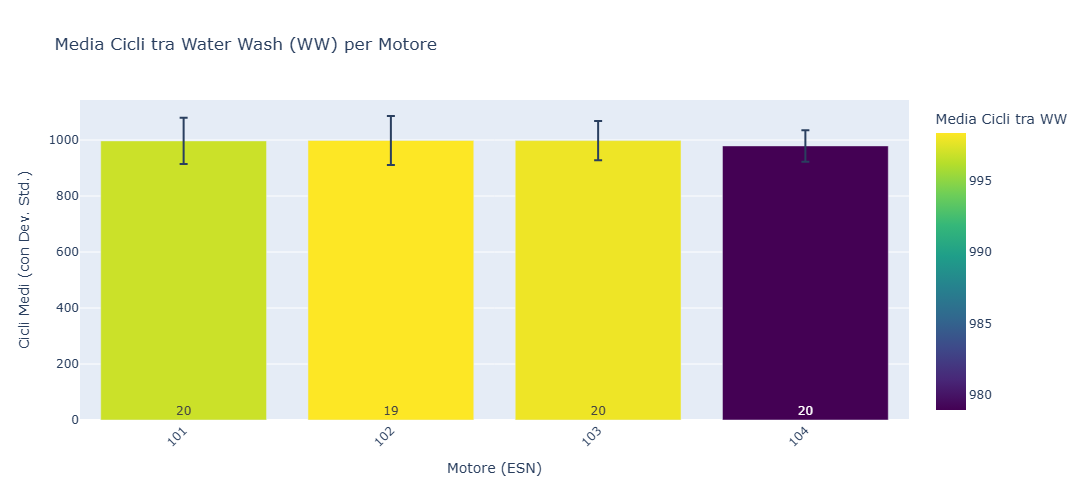

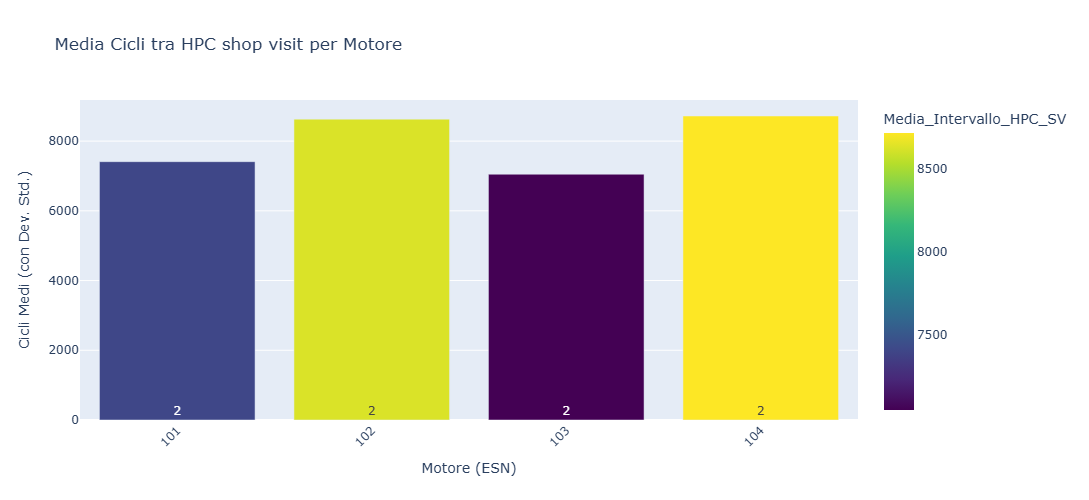

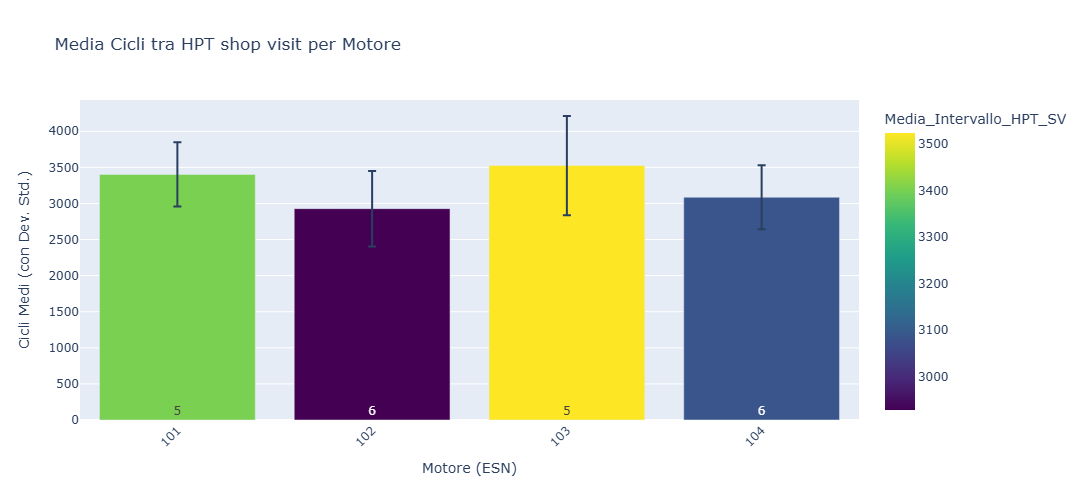

In [8]:
# Calcolo della media e della deviazione standard tra i cicli tra ogni ww per motore

wws_points_2 = wws_points.copy() # lavoro su una copia
wws_counts = wws_points_2.groupby('ESN').size().reset_index(name='Totale_Eventi_WW')
wws_points_2['cycles_between_ww'] = wws_points_2.groupby('ESN')['Cycles_Since_New'].diff()
ww_stats = wws_points_2.groupby('ESN').agg(
    Media_Intervallo_WW=('cycles_between_ww', 'mean'),
    DevStd_Intervallo_WW=('cycles_between_ww', 'std'),
    Num_Eventi=('ESN', 'count')
).reset_index()
print(ww_stats)

# Grafico per chiarezza
ww_stats['ESN'] = ww_stats['ESN'].astype(str)
fig_ww = px.bar(
    ww_stats, 
    x='ESN', 
    y='Media_Intervallo_WW',
    error_y='DevStd_Intervallo_WW',
    text='Num_Eventi',
    title='Media Cicli tra Water Wash (WW) per Motore',
    labels={
        'ESN': 'Motore (ESN)', 
        'Media_Intervallo_WW': 'Media Cicli tra WW',
        'Num_Eventi': 'Numero di eventi'
    },
    color='Media_Intervallo_WW',
    color_continuous_scale='Viridis'
)
fig_ww.update_traces(
    textposition='inside',    
    insidetextanchor='start'
)
fig_ww.update_layout(
    xaxis_tickangle=-45,
    yaxis_title="Cicli Medi (con Dev. Std.)",
    hovermode="x unified",
    height=500
)

# Calcolo della media e della deviazione standard tra i cicli tra ogni HPC_SV per motore
hpc_points_2 = hpc_points.copy() # lavoro su una copia
hpc_counts = hpc_points_2.groupby('ESN').size().reset_index(name='Totale_Eventi_HPC_SV')
hpc_points_2['cycles_between_hpc_sv'] = hpc_points_2.groupby('ESN')['Cycles_Since_New'].diff()
hpc_stats = hpc_points_2.groupby('ESN').agg(
    Media_Intervallo_HPC_SV=('cycles_between_hpc_sv', 'mean'),
    DevStd_Intervallo_HPC_SV=('cycles_between_hpc_sv', 'std'),
    Num_Eventi=('ESN', 'count')
).reset_index()
print(hpc_stats)
# Grafico per chiarezza
hpc_stats['ESN'] = hpc_stats['ESN'].astype(str)
fig_hpc = px.bar(
    hpc_stats, 
    x='ESN', 
    y='Media_Intervallo_HPC_SV',
    error_y='DevStd_Intervallo_HPC_SV',
    text='Num_Eventi',
    title='Media Cicli tra HPC shop visit per Motore',
    labels={
        'ESN': 'Motore (ESN)', 
        'Media_Intervallo_HCP_SV': 'Media Cicli tra HPC SV',
        'Num_Eventi': 'Numero di eventi'
    },
    color='Media_Intervallo_HPC_SV',
    color_continuous_scale='Viridis'
)
fig_hpc.update_traces(
    textposition='inside',    
    insidetextanchor='start'
)
fig_hpc.update_layout(
    xaxis_tickangle=-45,
    yaxis_title="Cicli Medi (con Dev. Std.)",
    hovermode="x unified",
    height=500
)

# Calcolo della media e della deviazione standard tra i cicli tra ogni HPT_SV per motore
hpt_points_2 = hpt_points.copy() # lavoro su una copia
hpt_counts = hpt_points.groupby('ESN').size().reset_index(name='Totale_Eventi_HPT_SV')
hpt_points_2['cycles_between_hpt_sv'] = hpt_points_2.groupby('ESN')['Cycles_Since_New'].diff()
hpt_stats = hpt_points_2.groupby('ESN').agg(
    Media_Intervallo_HPT_SV=('cycles_between_hpt_sv', 'mean'),
    DevStd_Intervallo_HPT_SV=('cycles_between_hpt_sv', 'std'),
    Num_Eventi=('ESN', 'count')
).reset_index()
print(hpt_stats)
# Grafico per chiarezza
hpt_stats['ESN'] = hpt_stats['ESN'].astype(str)
fig_hpt = px.bar(
    hpt_stats, 
    x='ESN', 
    y='Media_Intervallo_HPT_SV',
    error_y='DevStd_Intervallo_HPT_SV',
    text='Num_Eventi',
    title='Media Cicli tra HPT shop visit per Motore',
    labels={
        'ESN': 'Motore (ESN)', 
        'Media_Intervallo_HCT_SV': 'Media Cicli tra HPT SV',
        'Num_Eventi': 'Numero di eventi'
    },
    color='Media_Intervallo_HPT_SV',
    color_continuous_scale='Viridis'
)
fig_hpt.update_traces(
    textposition='inside',    
    insidetextanchor='start'
)
fig_hpt.update_layout(
    xaxis_tickangle=-45,
    yaxis_title="Cicli Medi (con Dev. Std.)",
    hovermode="x unified",
    height=500
)

# Stampa dei grafici
fig_ww.show()
fig_hpc.show()
fig_hpt.show()

In [ ]:
## Test per verificare la stazionarietà dei segnali dei sensori

Generazione dashboard per Motore ESN: 101...


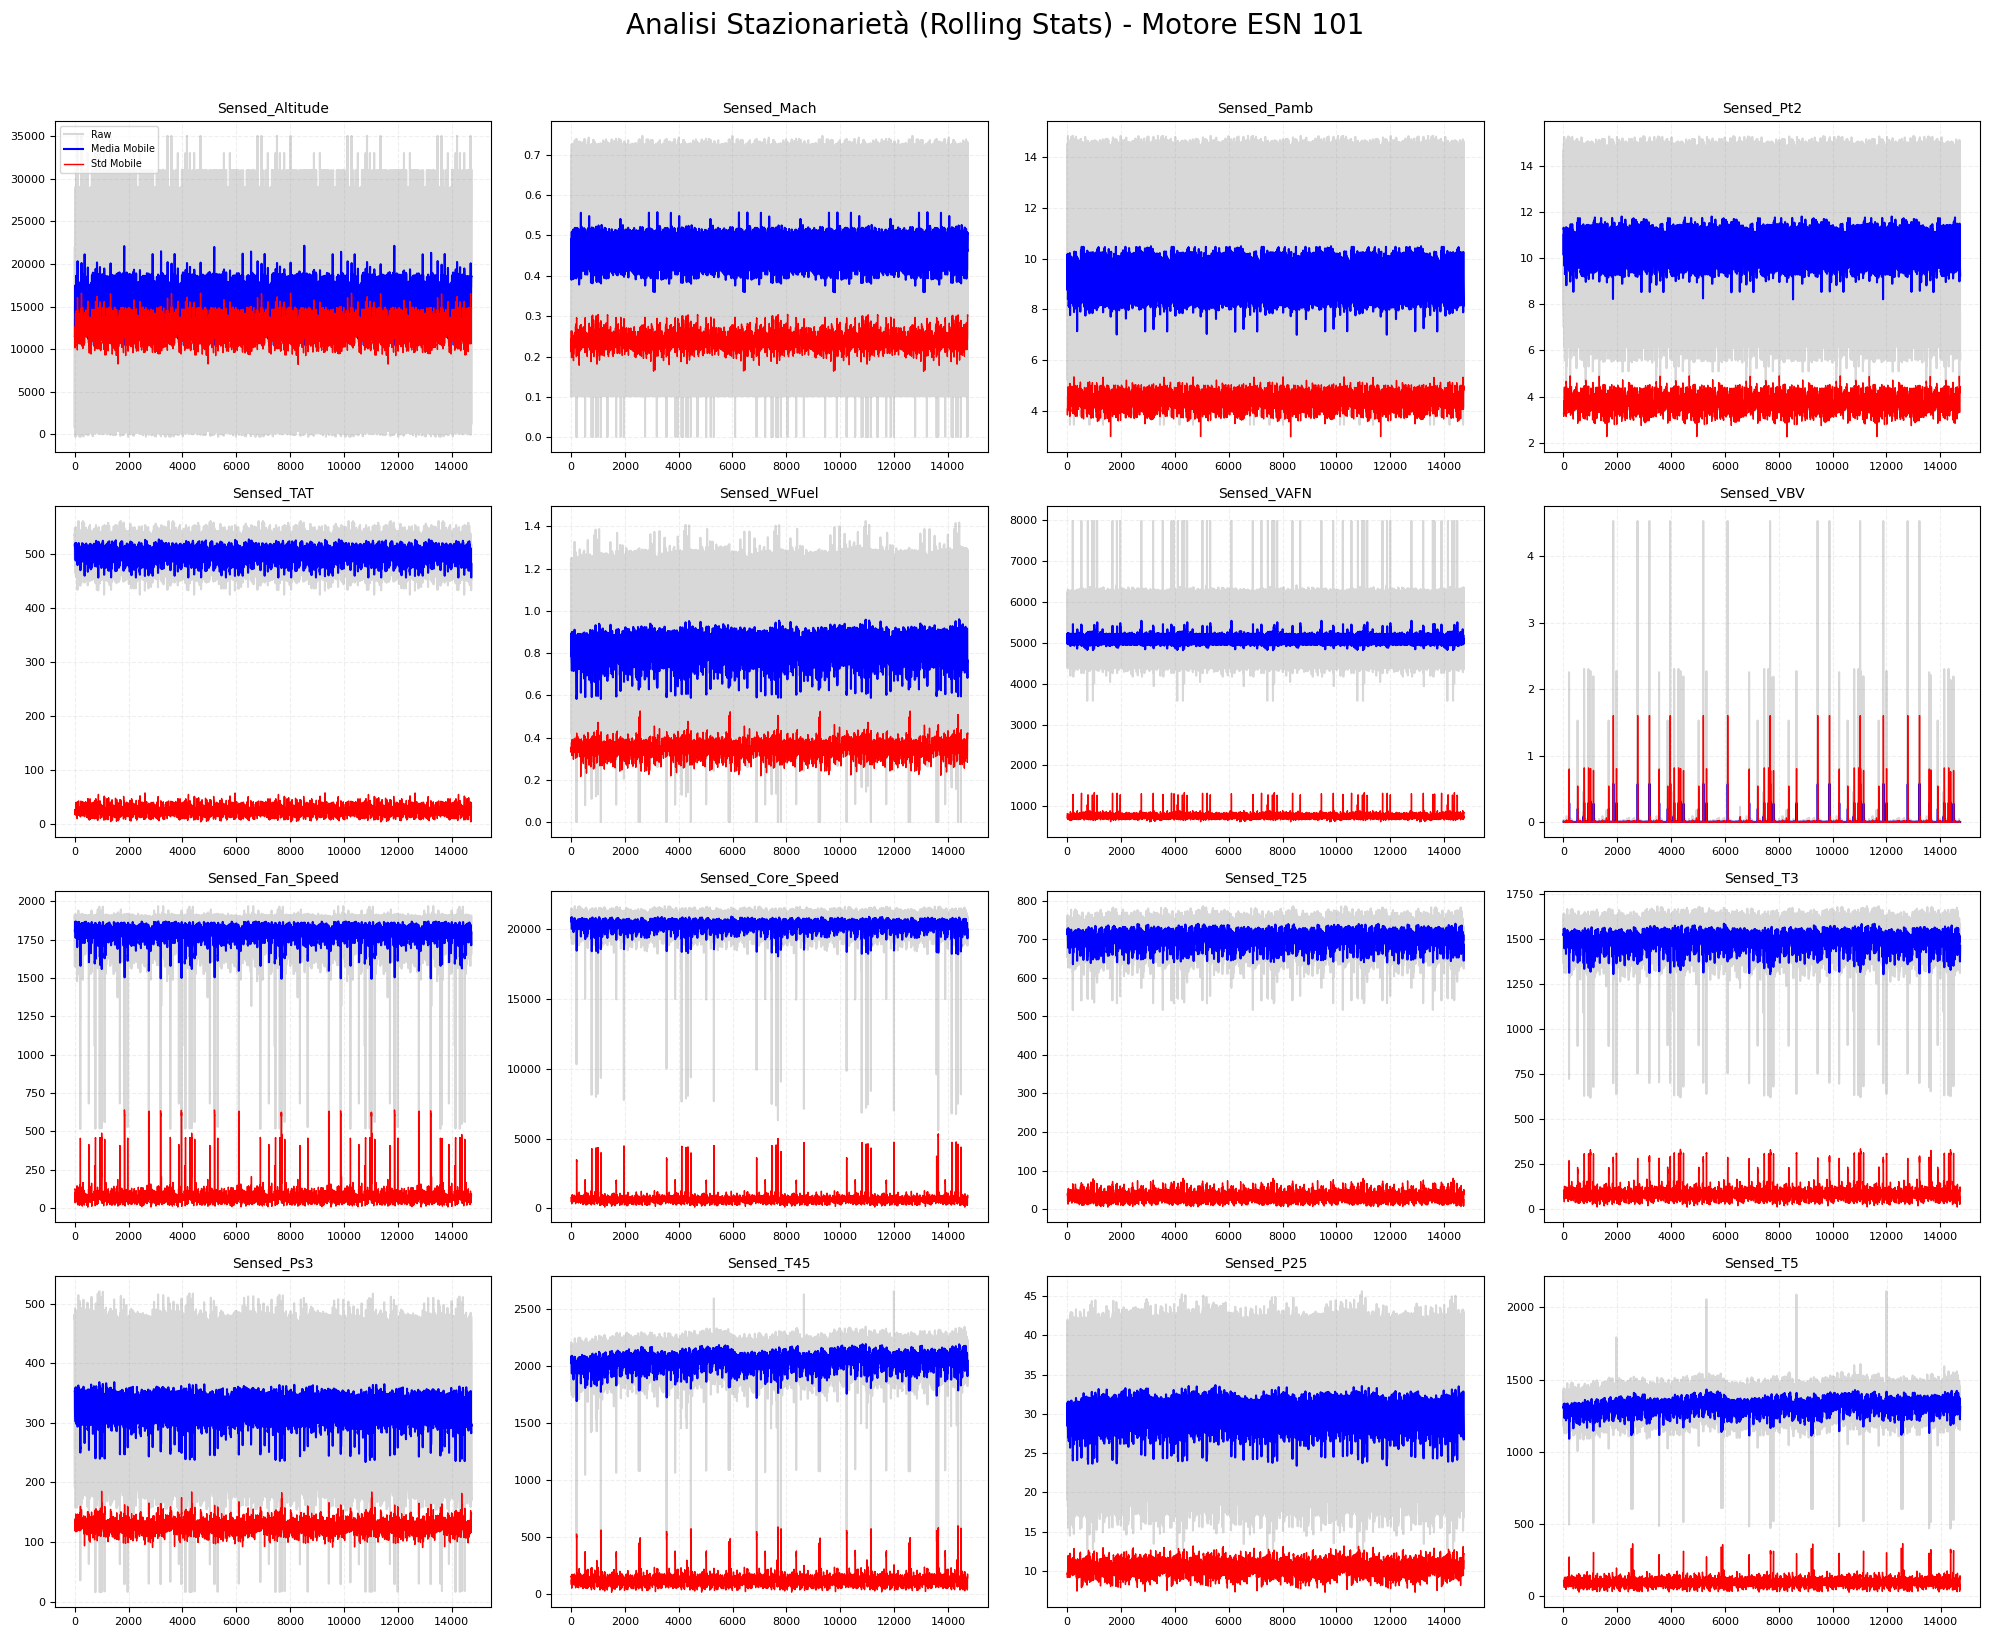

Generazione dashboard per Motore ESN: 102...


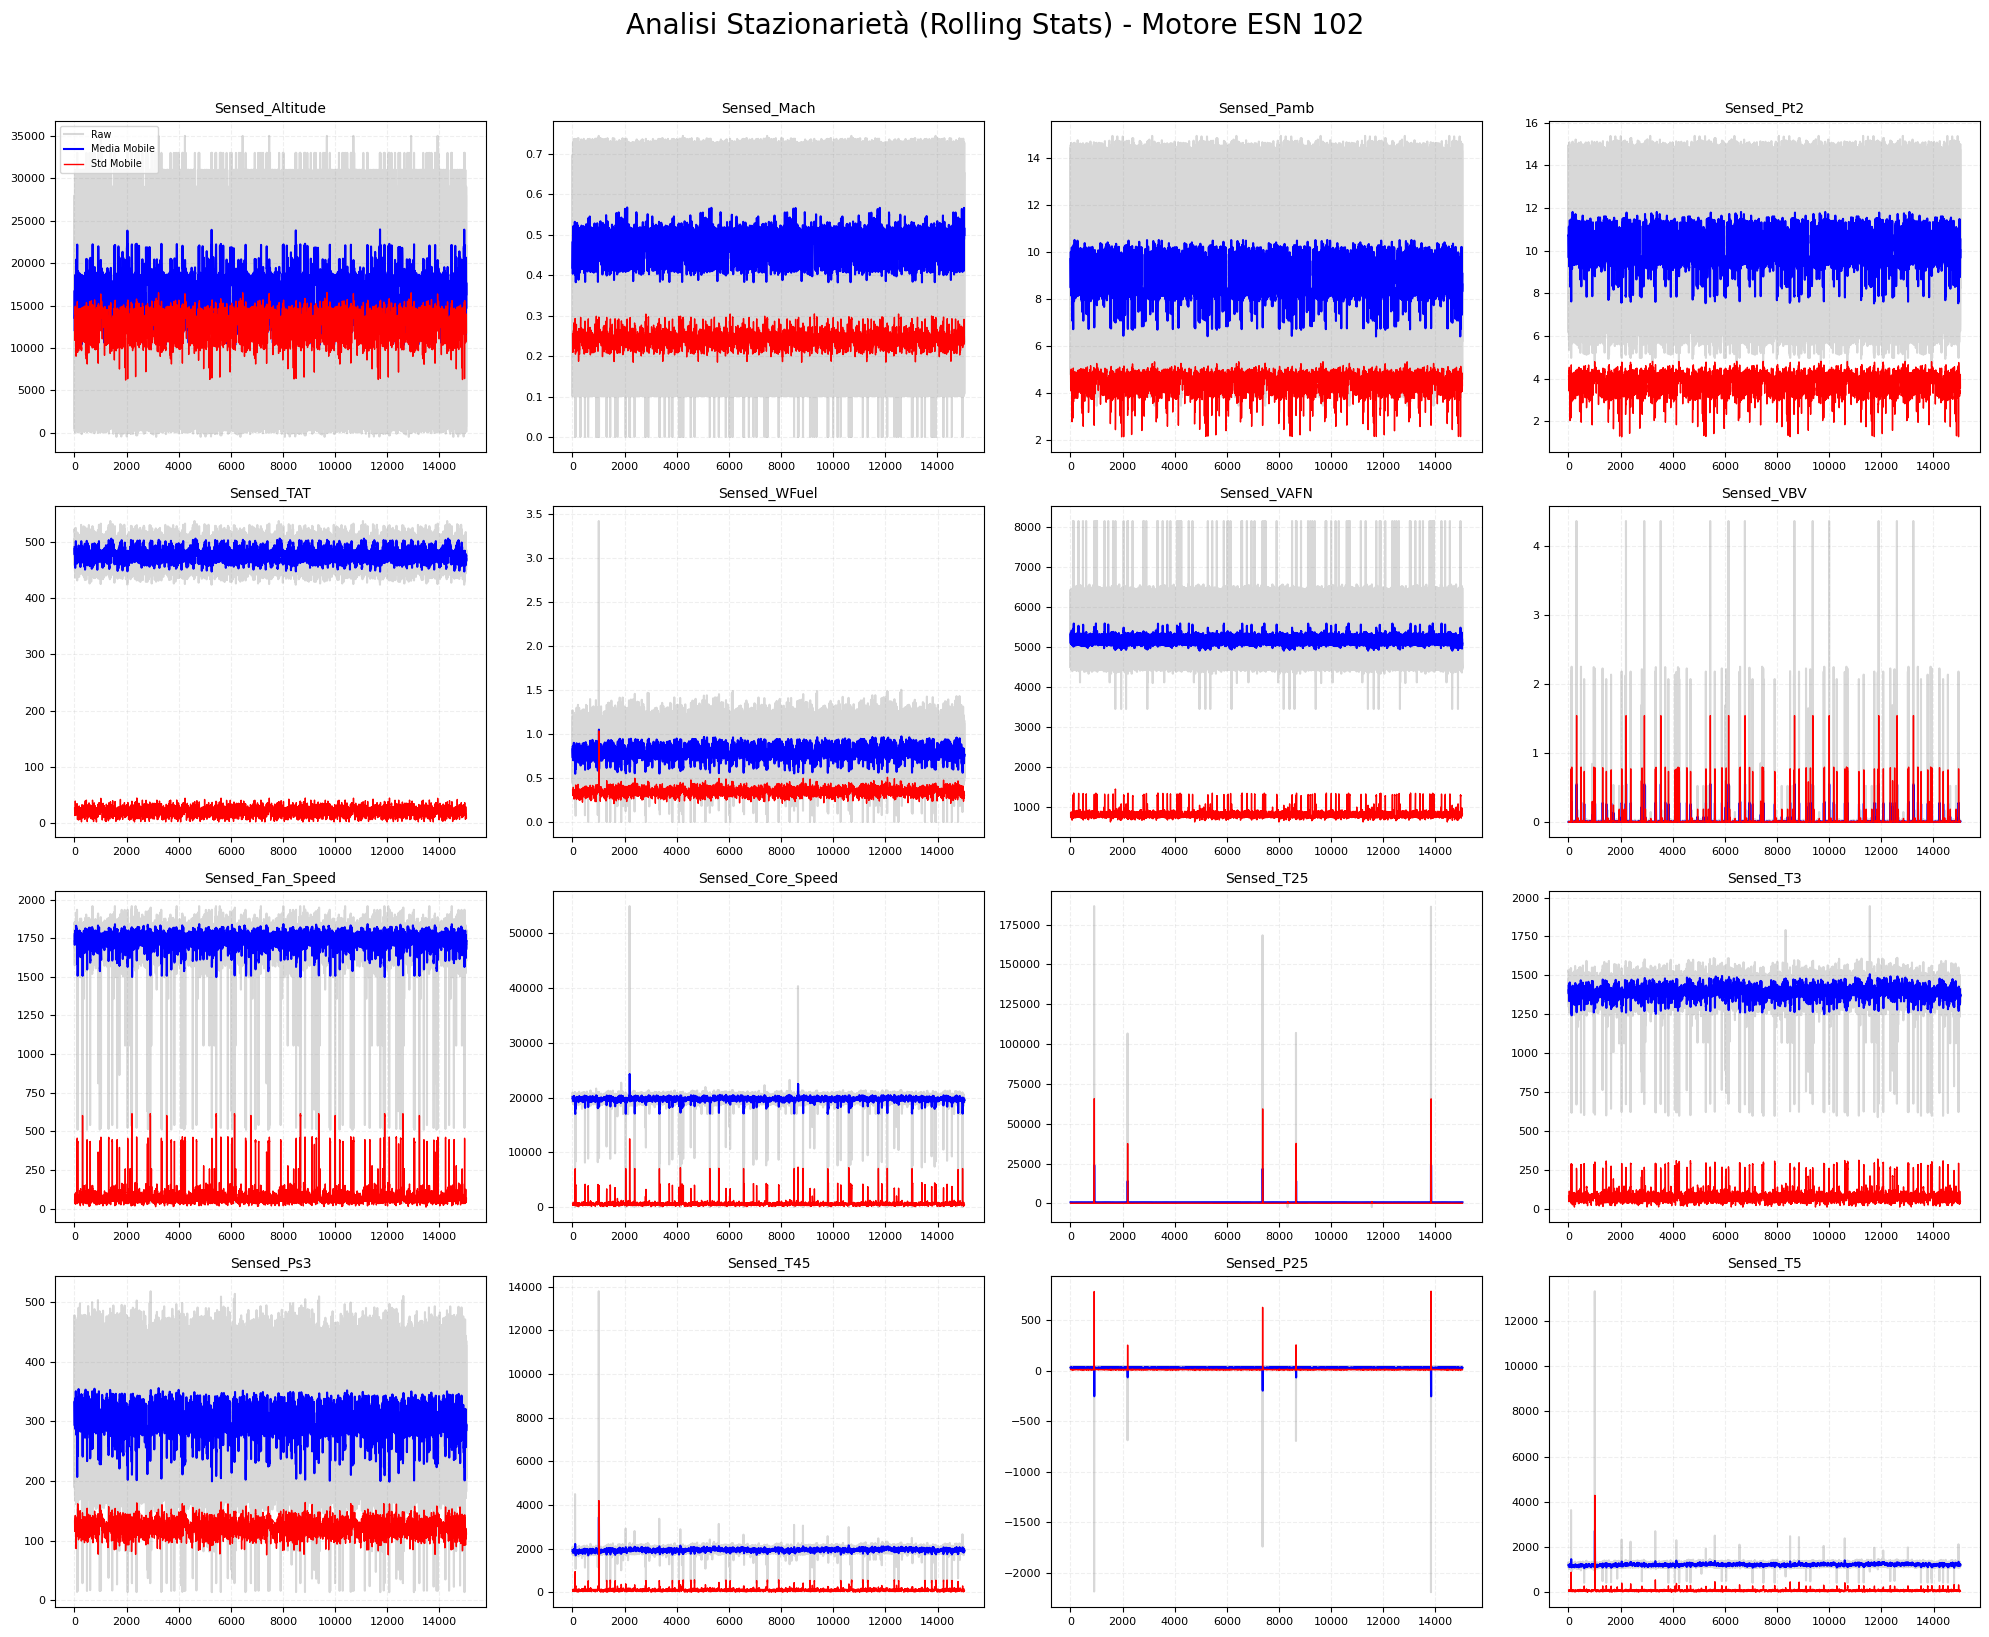

Generazione dashboard per Motore ESN: 103...


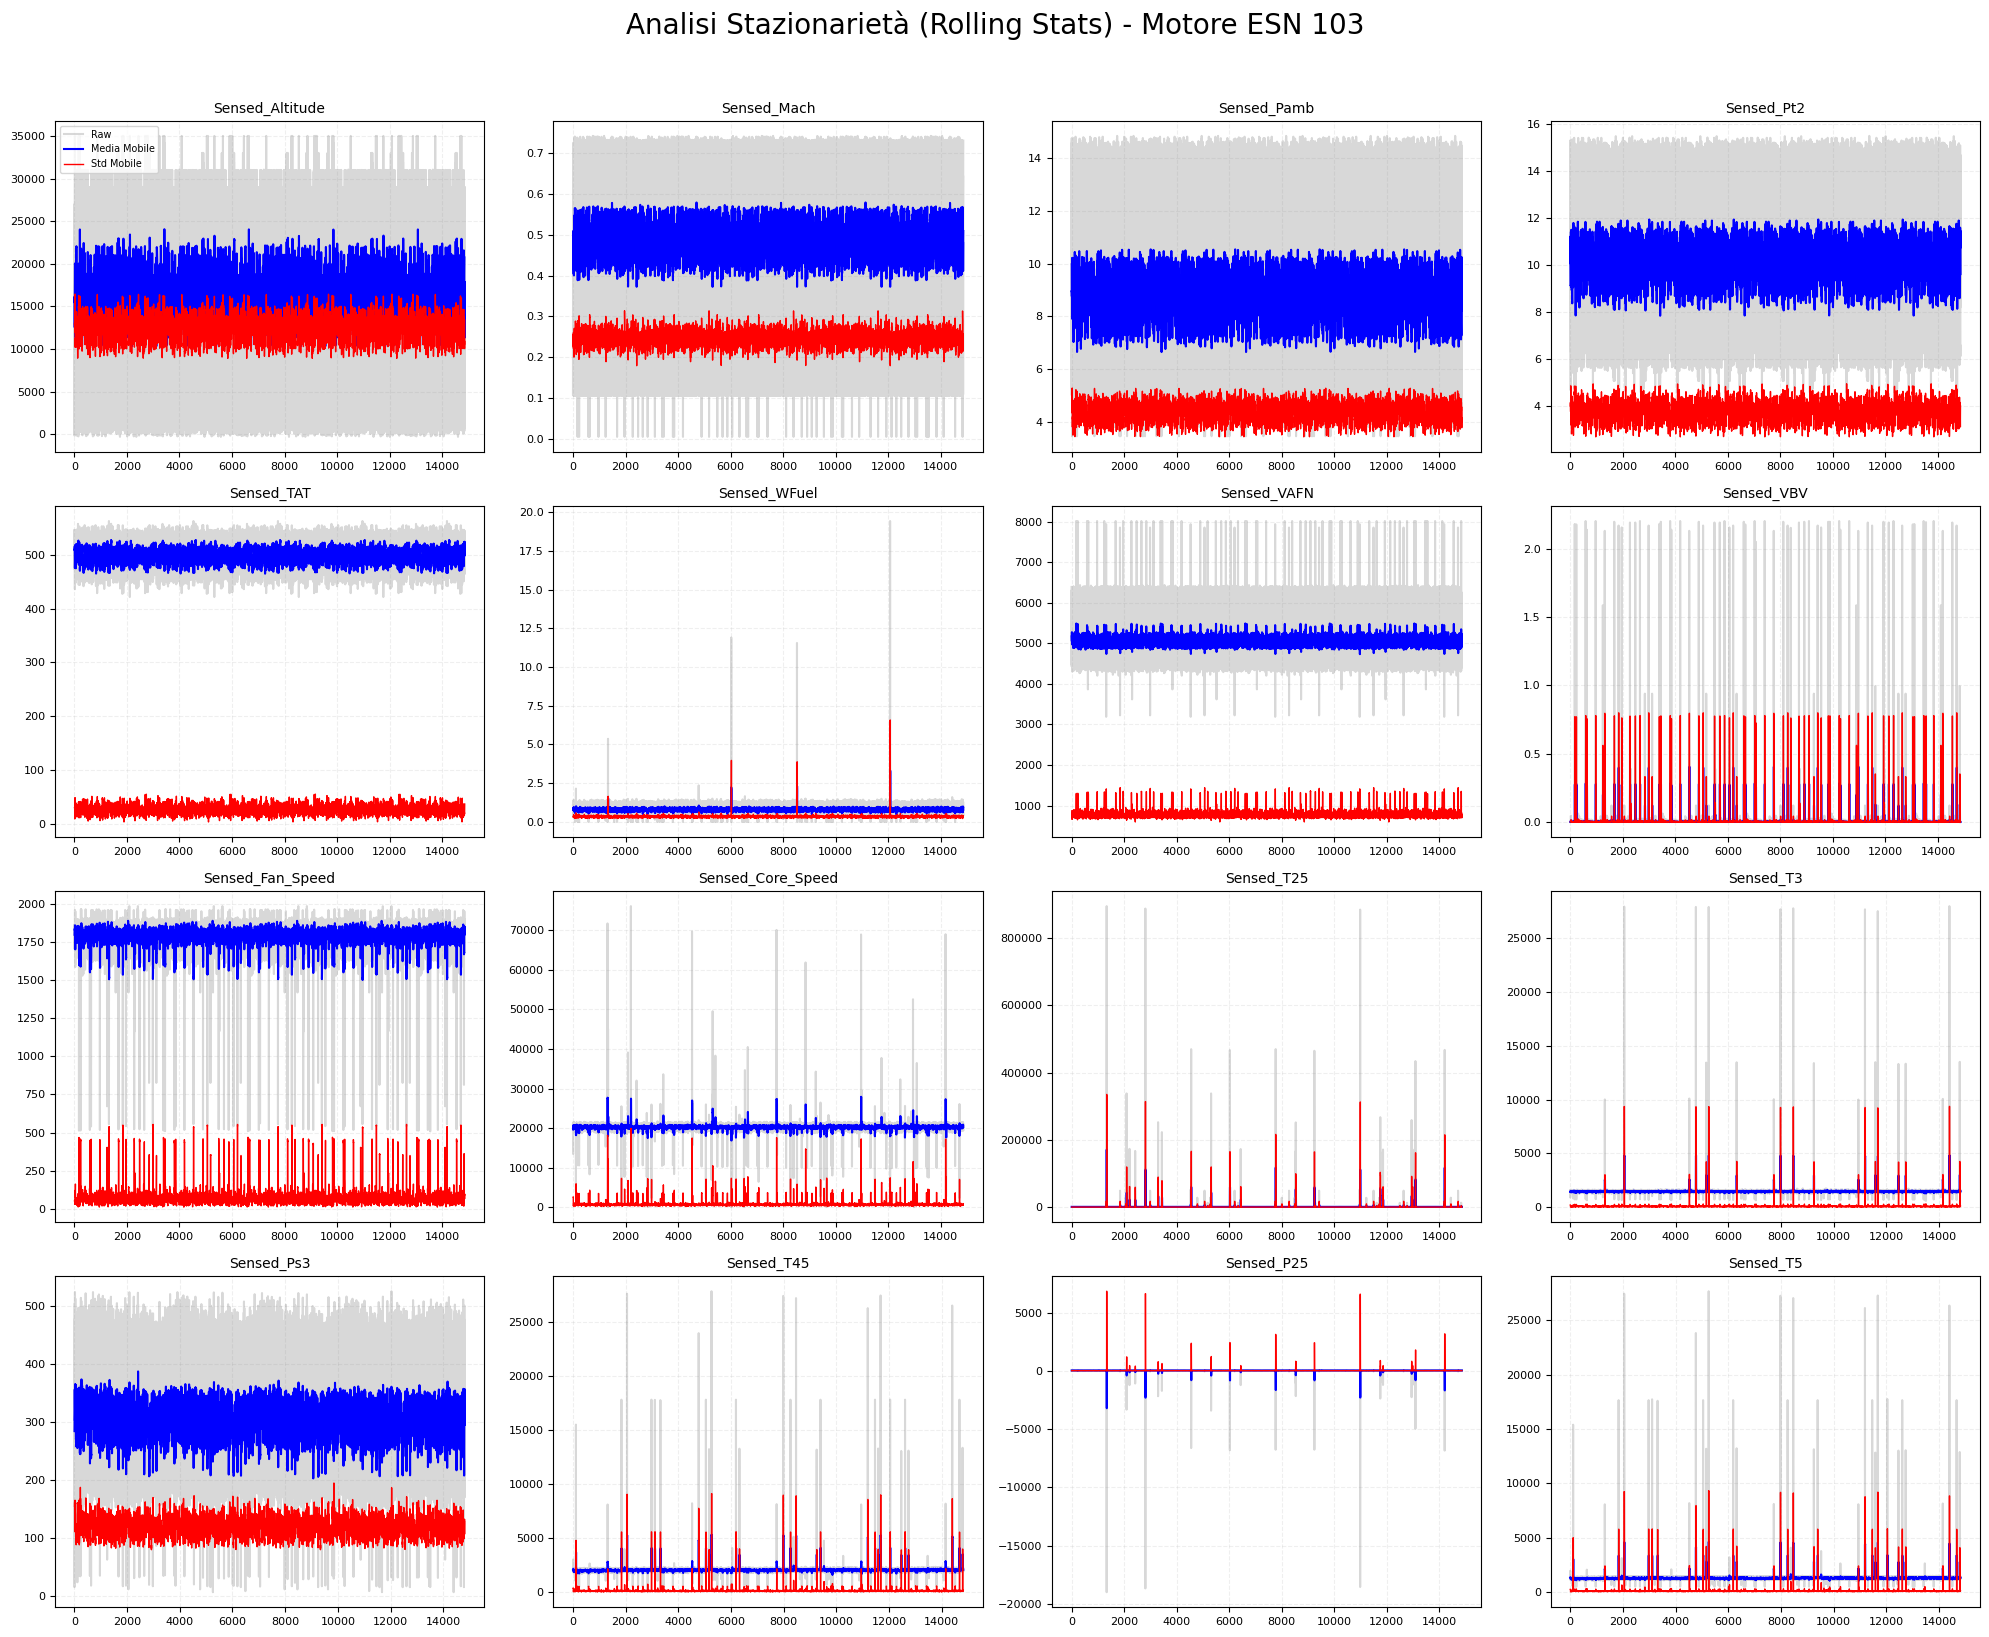

Generazione dashboard per Motore ESN: 104...


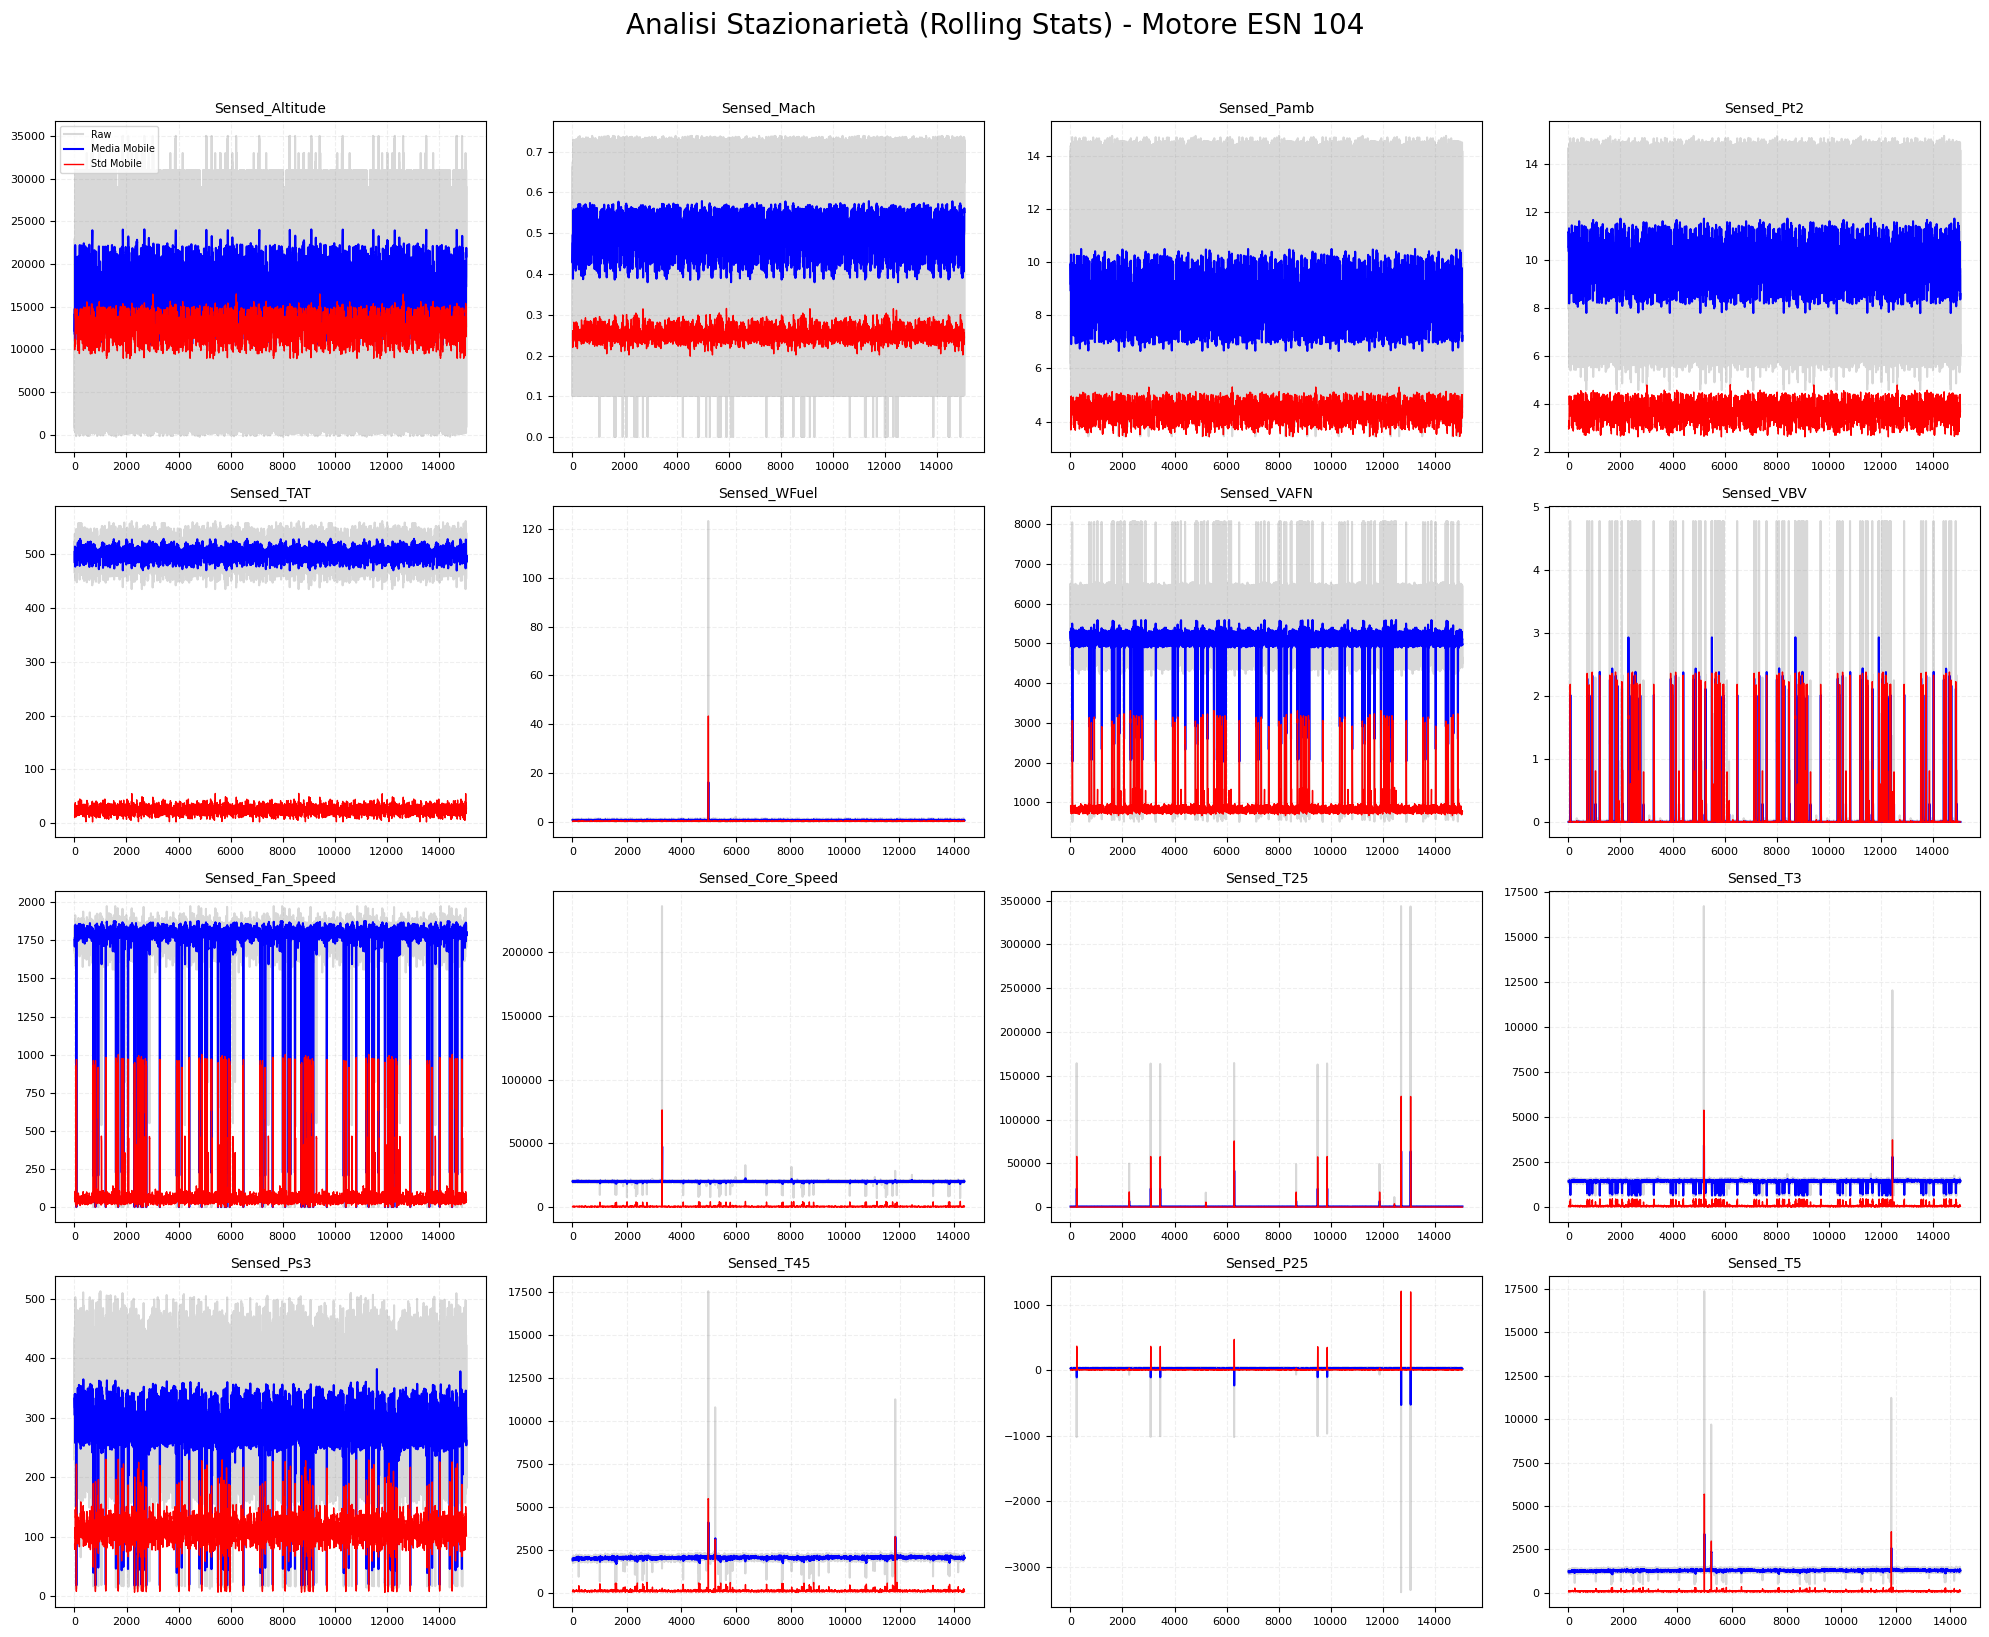

In [25]:
# Test controllo delle statistiche mobili dei segnali

for esn_id in globals.ESN:
    engine_data = train[train['ESN'] == esn_id].copy()
    fig, axes = plt.subplots(4, 4, figsize=(20, 16))
    axes = axes.flatten()
    print(f"Generazione dashboard per Motore ESN: {esn_id}...")
    for i, sensor in enumerate(globals.SENSORS):
        sensor_name = sensor.value if hasattr(sensor, 'value') else sensor
        ax = axes[i]
        series = engine_data[sensor_name].dropna()
        if len(series) > 8:
            roll_mean = series.rolling(window=8).mean()
            roll_std = series.rolling(window=8).std()
            # Plotting
            ax.plot(series.values, alpha=0.3, label='Raw', color='gray')
            ax.plot(roll_mean.values, label='Media Mobile', color='blue', linewidth=1.5)
            ax.plot(roll_std.values, label='Std Mobile', color='red', linewidth=1)
        else:
            ax.text(0.5, 0.5, 'Dati insufficienti', ha='center', va='center')
        # Formattazione singolo grafico
        ax.set_title(f"{sensor_name}", fontsize=10)
        ax.grid(True, alpha=0.2, linestyle='--')
        ax.tick_params(axis='both', which='major', labelsize=8)
        if i == 0:
            ax.legend(loc='upper left', fontsize='x-small')

    fig.suptitle(f"Analisi Stazionarietà - Motore ESN {esn_id}", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.savefig(f"Analisi_Stazionarieta_ESN_{esn_id}.png", bbox_inches='tight')
    plt.show()

In [24]:
# DA CONTROLLARE
# Test Augmented Dickey-Fuller

results_list = []

for esn_id in globals.ESN:
    # Filtriamo il dataframe per il motore corrente
    engine_data = train[train['ESN'] == esn_id]
    
    for sensor in globals.SENSORS:
        sensor_name = sensor.value if hasattr(sensor, 'value') else sensor
        series = engine_data[sensor_name].dropna()
        
        if series.nunique() <= 1:
            results_list.append({'ESN': esn_id, 'Sensor': sensor_name, 'p-value': np.nan, 'Stazionario': 'Dati Costanti'})
            continue
            
        try:
            res = adfuller(series)
            p_value = res[1]
            is_stationary = "SÌ" if p_value <= 0.05 else "NO"
            
            results_list.append({
                'ESN': esn_id, 
                'Sensor': sensor_name, 
                'p-value': round(p_value, 4), 
                'Stazionario': is_stationary
            })
        except Exception as e:
            results_list.append({'ESN': esn_id, 'Sensor': sensor_name, 'p-value': np.nan, 'Stazionario': 'Errore'})

# Dataframe ria
df_results = pd.DataFrame(results_list)

# Visualizzazione solo di quelli non stazionari
print(df_results[df_results['Stazionario'] == 'NO'].head(20))

Empty DataFrame
Columns: [ESN, Sensor, p-value, Stazionario]
Index: []


In [ ]:
# TODO: controllare stazionarietà per snapshot

In [9]:
sensors = ["Sensed_Altitude",
           "Sensed_Mach",
           "Sensed_Pamb",
           "Sensed_Pt2",
           "Sensed_TAT",
           "Sensed_WFuel",
           "Sensed_VAFN",
           "Sensed_VBV",
           "Sensed_Fan_Speed",
           "Sensed_Core_Speed",
           "Sensed_T25",
           "Sensed_T3",
           "Sensed_Ps3",
           "Sensed_T45",
           "Sensed_P25",
           "Sensed_T5"
]

def plot(df, sensor):
  fig = px.line(
        df,
        x=df['scaled_index'],
        y=sensor,
        color='ESN',
        title=f'Andamento del Sensore {sensor} Suddiviso per ESN',
        labels={'x':'Indice del Dato / Tempo (Sequenza)', 'y':f'Valore di {sensor}'},
        height=800,
        line_group='ESN' # Garantisce che i punti siano collegati correttamente per ogni gruppo ESN
    )

  # Aggiorna il layout per un aspetto migliore (opzionale)
  fig.update_xaxes(rangeslider_visible=True) # Aggiunge uno slider in basso per navigare nel tempo

  # Mostra il grafico interattivo in Colab/Jupyter
  fig.show()

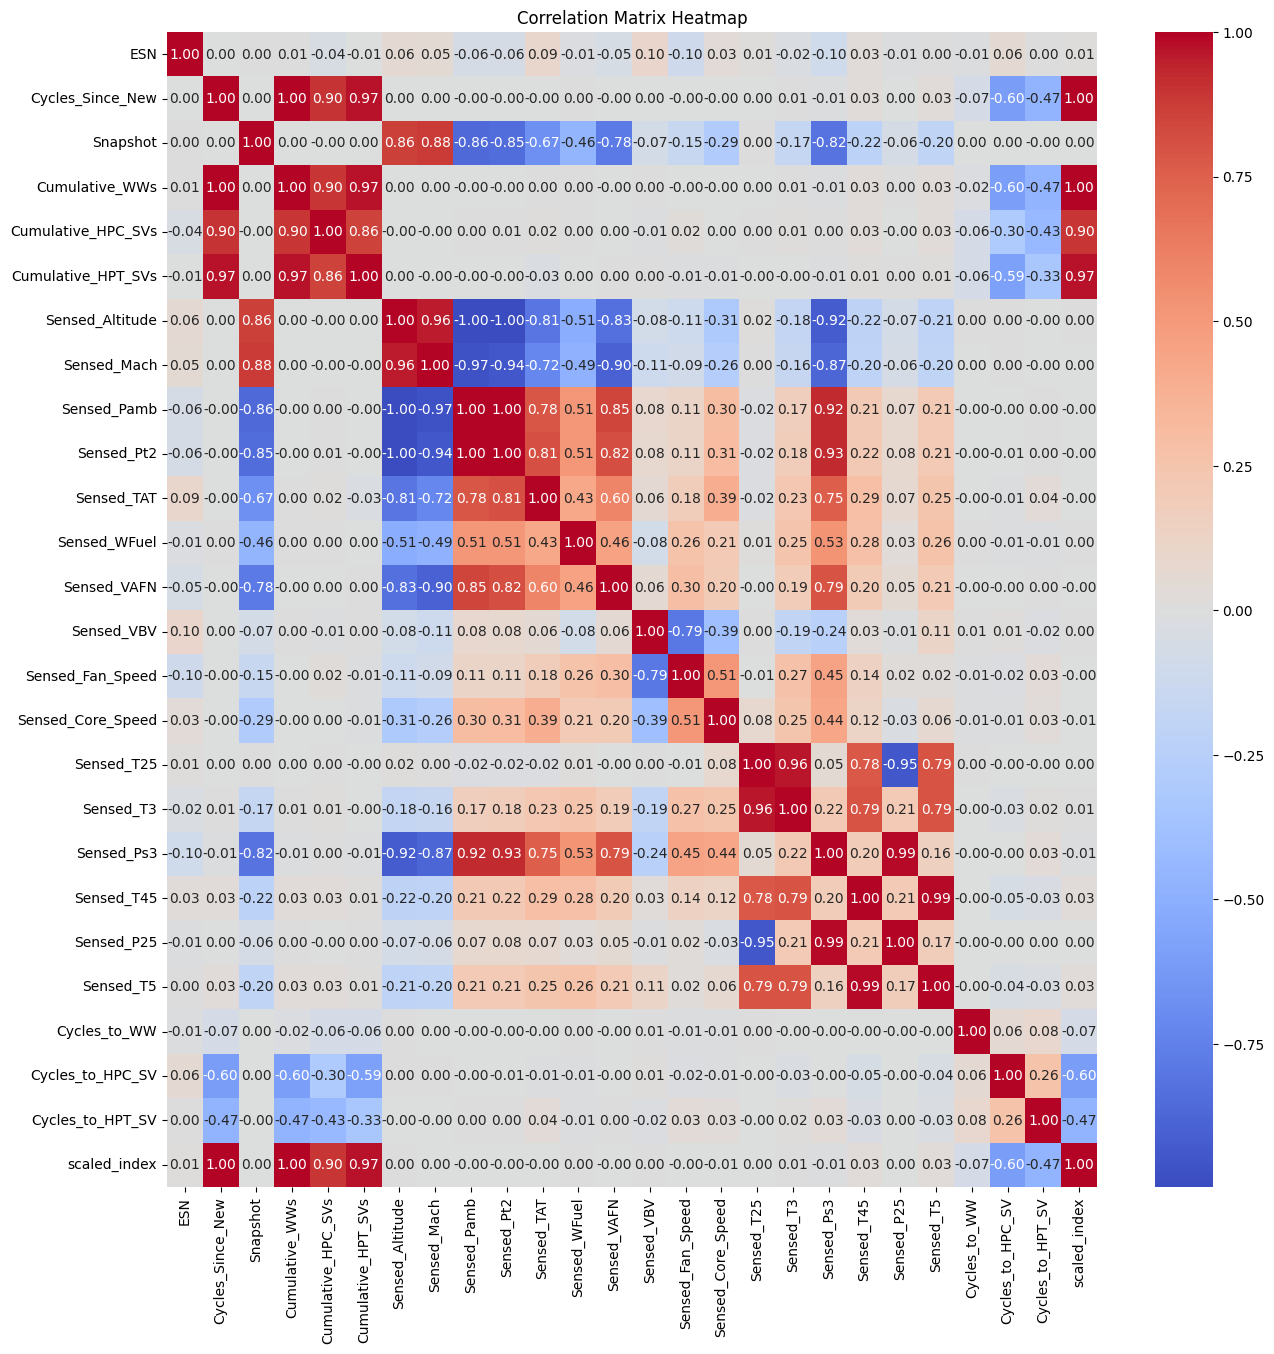

In [10]:
# Matrice di correlazione delle colonne
# Utile per PCA futura
cm = train.corr()

plt.figure(figsize=(15,15))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [11]:
# Mappatura dei colori per gli eventi di manutenzione
EVENT_COLORS = {
    'Cumulative_WWs': 'red',
    'Cumulative_HPC_SVs': 'blue',
    'Cumulative_HPT_SVs': 'green'
}

def create_figure(df, sensor_name, wws_df, hpc_df, hpt_df, esn):
    """Crea una figura Plotly per il sensore specificato."""
    
    df = df[df["ESN"] == esn].copy()
    df.reset_index(drop=True, inplace=True)  # indice locale 0..N-1
    wws_df = wws_df[wws_df["ESN"] == esn]
    hpc_df = hpc_df[hpc_df["ESN"] == esn]
    hpt_df = hpt_df[hpt_df["ESN"] == esn]
    
    fig = px.line(
        df,
        x=df.index,
        y=sensor_name,
        color='ESN',
        title=f'Andamento del Sensore {sensor_name} Suddiviso per ESN',
        labels={'x':'Indice del Dato / Tempo (Sequenza)', 'y':f'Valore di {sensor_name}'},
        height=800,
        line_group='ESN'
    )
    
    for index, row in wws_df.iterrows():
        fig.add_vline(
            x=row.scaled_index,
            line_width=1, line_dash="dash", line_color=EVENT_COLORS['Cumulative_WWs'],
            name='WWs Event',
            # Aggiunge un'annotazione per identificare il tipo di evento
            annotation_text="WWs", annotation_position="top right",
            annotation_font_color=EVENT_COLORS['Cumulative_WWs']
        )
    
    # Eventi Cumulative_HPC_SVs (Manutenzione HPC)
    for index, row in hpc_df.iterrows():
        fig.add_vline(
            x=row.scaled_index,
            line_width=1, line_dash="dash", line_color=EVENT_COLORS['Cumulative_HPC_SVs'],
            name='HPC_SV Event',
            annotation_text="HPC_SV", annotation_position="top left",
            annotation_font_color=EVENT_COLORS['Cumulative_HPC_SVs']
        )
        
    # Eventi Cumulative_HPT_SVs (Manutenzione HPT)
    for index, row in hpt_df.iterrows():
        fig.add_vline(
            x=row.scaled_index,
            line_width=1, line_dash="dash", line_color=EVENT_COLORS['Cumulative_HPT_SVs'],
            name='HPT_SV Event',
            annotation_text="HPT_SV", annotation_position="bottom right",
            annotation_font_color=EVENT_COLORS['Cumulative_HPT_SVs']
        )


    fig.update_layout(
        title=f'Andamento del sensore "{sensor_name}" vs Cicli con Eventi di Manutenzione',
        xaxis_title='Cicli Dall\'Inizio (Cycles_Since_New)',
        yaxis_title=sensor_name,
        legend_title="ESN (Motore)",
        height=600,
        hovermode="x unified"
    )

    return fig


def update_plot(sensor_name, data, esn):
    return create_figure(data, sensor_name, wws_points, hpc_points, hpt_points, esn)

In [ ]:
for sensor in sensors:
    for esn in train["ESN"].unique():
        fig = update_plot(sensor, train, esn)
        iplot(fig)

In [ ]:
esn101 = train[train['ESN'] == 101 ]
N = len(esn101) # Get the number of rows
esn101['i'] = pd.RangeIndex(start=0, stop=N)

esn102 = train[train['ESN'] == 102 ]
N = len(esn102) # Get the number of rows
esn102['i'] = pd.RangeIndex(start=0, stop=N)

esn103 = train[train['ESN'] == 103 ]
N = len(esn103) # Get the number of rows
esn103['i'] = pd.RangeIndex(start=0, stop=N)

esn104 = train[train['ESN'] == 104 ]
N = len(esn104) # Get the number of rows
esn104['i'] = pd.RangeIndex(start=0, stop=N)


train_2 = pd.concat([esn101, esn102, esn103, esn104], axis=0)

In [ ]:
sensors = ["Sensed_Altitude", "Sensed_Mach", "Sensed_Pamb", "Sensed_Pt2", "Sensed_TAT", "Sensed_WFuel",
           "Sensed_VAFN", "Sensed_VBV", "Sensed_Fan_Speed", "Sensed_Core_Speed", "Sensed_T25",
           "Sensed_T3", "Sensed_Ps3", "Sensed_T45", "Sensed_P25", "Sensed_T5"]

def plot(df, sensor):
  fig = px.line(
        df,
        x=df['i'],
        y=sensor,
        color='ESN',
        title=f'Andamento del Sensore {sensor} Suddiviso per ESN',
        labels={'x':'Indice del Dato / Tempo (Sequenza)', 'y':f'Valore di {sensor}'},
        height=800,
        line_group='ESN' # Garantisce che i punti siano collegati correttamente per ogni gruppo ESN
    )

  # Aggiorna il layout per un aspetto migliore (opzionale)
  fig.update_xaxes(rangeslider_visible=True) # Aggiunge uno slider in basso per navigare nel tempo

  # Mostra il grafico interattivo in Colab/Jupyter
  fig.show()

In [ ]:
plot(train_2[train_2['ESN'] == 101], sensors[0])

In [ ]:
# # Identificazione degli eventi di manutenzione (cambio nei contatori cumulativi)
# event_data = train.copy()

# # Calcola la differenza per identificare i cicli in cui i contatori cumulativi cambiano
# event_data['WWs_Change'] = event_data.groupby('ESN')['Cumulative_WWs'].diff().fillna(0)
# event_data['HPC_SVs_Change'] = event_data.groupby('ESN')['Cumulative_HPC_SVs'].diff().fillna(0)
# event_data['HPT_SVs_Change'] = event_data.groupby('ESN')['Cumulative_HPT_SVs'].diff().fillna(0)

# # Filtra per trovare solo i cicli in cui si è verificato un evento (cambio > 0)
# # Questi saranno usati per disegnare le linee verticali.
# wws_events = event_data[event_data['WWs_Change'] > 0]
# hpc_events = event_data[event_data['HPC_SVs_Change'] > 0]
# hpt_events = event_data[event_data['HPT_SVs_Change'] > 0]

# # Elenco dei sensori da plottare (tutte le colonne numeriche escluse le colonne ID/Cumulative)
# id_cols = ['ESN', 'Cycles_Since_New', 'Snapshot', 'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']
# cumulative_cols = ['Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs']
# change_cols = ['WWs_Change', 'HPC_SVs_Change', 'HPT_SVs_Change']

# sensor_cols = [col for col in train.columns if col not in id_cols + cumulative_cols + change_cols]
# print("\nColonne Sensore disponibili per il plot:")
# print(sensor_cols)

# # Colonna sensore di default
# DEFAULT_SENSOR = 'Sensed_T25'